In [2]:
#importing modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score,
    precision_score, jaccard_score,
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.facecolor']   = '#141414'
plt.rcParams['axes.edgecolor']   = '#333333'
plt.rcParams['axes.labelcolor']  = '#cccccc'
plt.rcParams['text.color']       = '#cccccc'
plt.rcParams['xtick.color']      = '#888888'
plt.rcParams['ytick.color']      = '#888888'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['font.family']      = 'monospace'

print("✅ Libraries loaded")
print(f"   NumPy     {np.__version__}")
print(f"   Pandas    {pd.__version__}")
import sklearn; print(f"   Sklearn   {sklearn.__version__}")


✅ Libraries loaded
   NumPy     2.4.2
   Pandas    3.0.1
   Sklearn   1.8.0


In [3]:
#DATA GEN
WINDOW   = 120    
N_CRASH  = 4500
N_NORMAL = 5500   

def make_window(crash=False):
    speed = np.random.uniform(5, 130)
    ax = np.random.normal(9.8, 2, WINDOW)
    ay = np.random.normal(0, 1.5, WINDOW)
    az = np.random.normal(0, 1.5, WINDOW)
    gx = np.random.normal(0, 1, WINDOW)
    gy = np.random.normal(0, 1, WINDOW)
    gz = np.random.normal(0, 1, WINDOW)
    spd = np.full(WINDOW, speed, dtype=float)

    if crash:
        severity = np.random.choice(['severe','moderate','mild'], p=[0.35,0.40,0.25])
        peak = {'severe': np.random.uniform(60,90),
                'moderate': np.random.uniform(30,60),
                'mild': np.random.uniform(14,32)}[severity]
        start = np.random.randint(20, 80)
        dur   = np.random.randint(8, 22)
        for i in range(start, min(start+dur, WINDOW)):
            t = np.sin(np.pi*(i-start)/max(dur,1))
            ax[i] += peak*t + np.random.normal(0,8)
            ay[i] += np.random.normal(0,12)*t
            az[i] += np.random.normal(0,12)*t
            gx[i] += np.random.uniform(8,40)*t + np.random.normal(0,5)
            spd[i] = max(speed - (i-start)*np.random.uniform(2,5), 0)
        p = min(start+dur, WINDOW-1)
        ax[p:] = np.random.normal(0, 2, WINDOW-p)
        az[p:] = np.random.normal(9.8, 1.5, WINDOW-p)
        spd[p:] = np.random.uniform(0, 2, WINDOW-p)
        if severity == 'mild':
            ax += np.random.normal(0, 3, WINDOW)
    else:
        n_bumps = np.random.randint(0, 4)
        for _ in range(n_bumps):
            i = np.random.randint(0, WINDOW-5)
            ax[i:i+4] += np.random.normal(0, np.random.uniform(5,20))
        if np.random.random() < 0.2:
            b = np.random.randint(20, 80)
            ax[b:b+15] -= np.random.uniform(5, 15)

    return np.column_stack([ax, ay, az, gx, gy, gz, spd])

print("Generating normal riding windows...")
normal_windows = [make_window(crash=False) for _ in range(N_NORMAL)]
print("Generating crash windows...")
crash_windows  = [make_window(crash=True)  for _ in range(N_CRASH)]
print(f"\n✅ Generated {N_NORMAL + N_CRASH:,} total samples")
print(f"   Normal: {N_NORMAL:,}  |  Crash: {N_CRASH:,}")


Generating normal riding windows...
Generating crash windows...

✅ Generated 10,000 total samples
   Normal: 5,500  |  Crash: 4,500


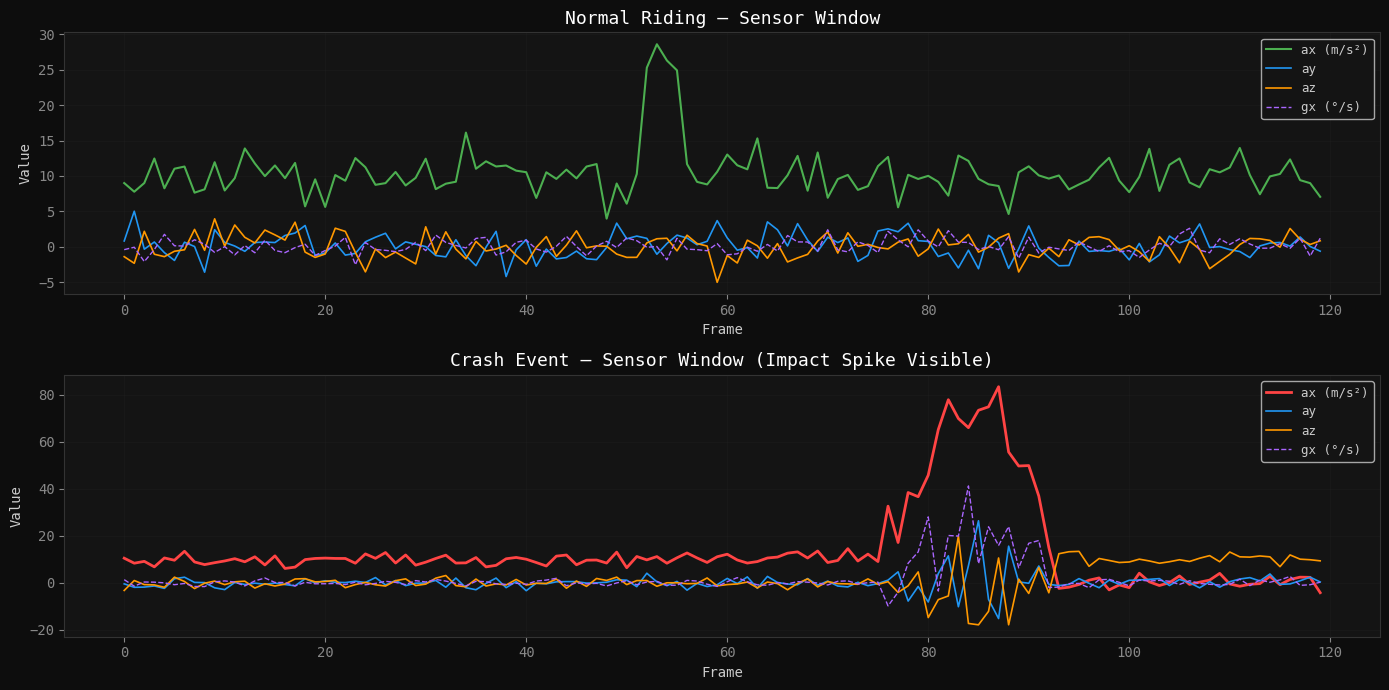


Red spike in crash window = impact moment


In [4]:

#viz samples
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# Normal sample
nw = normal_windows[42]
t  = np.arange(WINDOW)
axes[0].plot(t, nw[:,0], color='#4caf50', lw=1.5, label='ax (m/s²)')
axes[0].plot(t, nw[:,1], color='#2196f3', lw=1.2, label='ay')
axes[0].plot(t, nw[:,2], color='#ff9800', lw=1.2, label='az')
axes[0].plot(t, nw[:,3], color='#aa66ff', lw=1.0, ls='--', label='gx (°/s)')
axes[0].set_title('Normal Riding — Sensor Window', color='#ffffff', fontsize=13)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Crash sample
cw = crash_windows[10]
axes[1].plot(t, cw[:,0], color='#ff4444', lw=2, label='ax (m/s²)')
axes[1].plot(t, cw[:,1], color='#2196f3', lw=1.2, label='ay')
axes[1].plot(t, cw[:,2], color='#ff9800', lw=1.2, label='az')
axes[1].plot(t, cw[:,3], color='#aa66ff', lw=1.0, ls='--', label='gx (°/s)')
axes[1].set_title('Crash Event — Sensor Window (Impact Spike Visible)', color='#ffffff', fontsize=13)
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, alpha=0.3)

for ax_ in axes:
    ax_.set_xlabel('Frame', fontsize=10)
    ax_.set_ylabel('Value', fontsize=10)

plt.tight_layout()
plt.show()
print("\nRed spike in crash window = impact moment")


In [5]:
#feature extraction
def extract_features(w):
    feats = []
    for col in range(w.shape[1]):
        c = w[:, col]
        feats += [
            c.mean(), c.std(), c.min(), c.max(), c.max()-c.min(),
            np.percentile(c,10), np.percentile(c,90),
            np.sqrt(np.mean(c**2)),           
            np.mean(np.abs(np.diff(c))),       
            np.sum(np.abs(np.diff(c))),        
        ]
    mag = np.sqrt(w[:,0]**2 + w[:,1]**2 + w[:,2]**2)
    feats += [
        mag.max(), mag.mean(), mag.std(),
        np.percentile(mag,90), np.percentile(mag,95),
        float(np.sum(mag > 20)),
        float(np.sum(mag > 35)),
        float(np.sum(mag > 50)),
    ]
    spd = w[:,6]
    feats += [float(spd.max()-spd.min()), float(np.diff(spd).min())]
    return feats

print("Extracting features...")
X_norm  = np.array([extract_features(w) for w in normal_windows])
X_crash = np.array([extract_features(w) for w in crash_windows])
X = np.vstack([X_norm, X_crash])
y = np.concatenate([np.zeros(N_NORMAL,int), np.ones(N_CRASH,int)])

flip_idx = np.random.choice(len(y), size=int(0.03*len(y)), replace=False)
y[flip_idx] = 1 - y[flip_idx]

print(f"✅ Feature matrix: {X.shape[0]:,} samples × {X.shape[1]} features")
print(f"   Class 0 (Normal): {np.sum(y==0):,}")
print(f"   Class 1 (Crash) : {np.sum(y==1):,}")

df_sample = pd.DataFrame(X[:5], columns=[f'f{i}' for i in range(X.shape[1])])
print(f"\nFirst 5 samples (showing first 10 features):")
print(df_sample.iloc[:, :10].round(3).to_string())


Extracting features...
✅ Feature matrix: 10,000 samples × 80 features
   Class 0 (Normal): 5,464
   Class 1 (Crash) : 4,536

First 5 samples (showing first 10 features):
       f0     f1      f2      f3      f4     f5      f6      f7     f8       f9
0   9.662  1.979   4.490  16.545  12.055  7.477  11.895   9.862  2.034  242.086
1  10.437  2.979   4.375  20.774  16.399  6.569  12.540  10.854  2.513  299.042
2   7.318  8.582 -34.748  20.111  54.859 -0.411  12.230  11.279  2.799  333.026
3   9.901  2.333   2.857  18.922  16.064  7.250  12.244  10.172  2.257  268.574
4   9.552  1.920   5.327  13.962   8.634  6.946  11.790   9.743  2.072  246.515


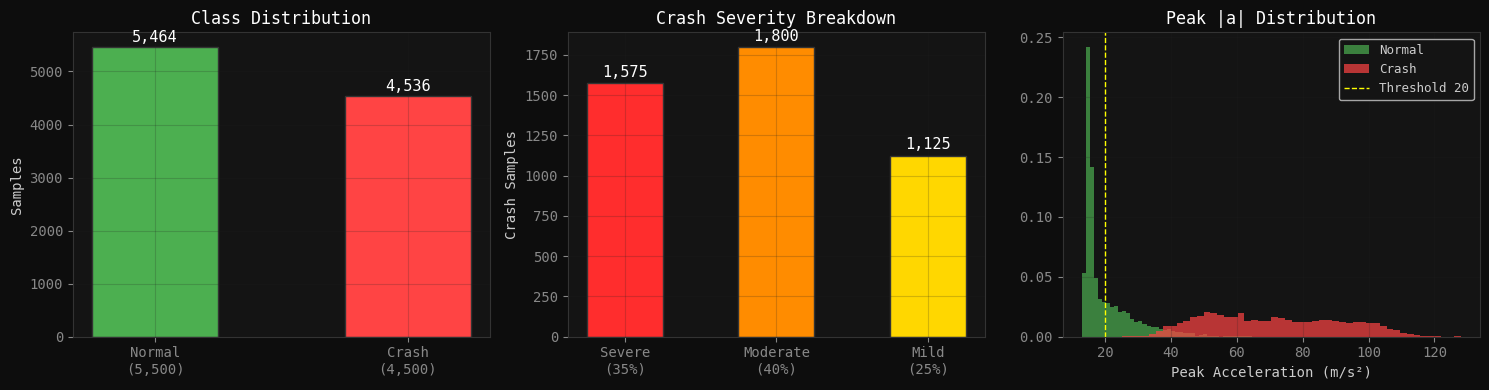

In [6]:
#dataset overview
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

classes = ['Normal\n(5,500)', 'Crash\n(4,500)']
counts  = [np.sum(y==0), np.sum(y==1)]
colors  = ['#4caf50', '#ff4444']
bars = axes[0].bar(classes, counts, color=colors, width=0.5, edgecolor='#333')
axes[0].set_title('Class Distribution', color='white', fontsize=12)
axes[0].set_ylabel('Samples', fontsize=10)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+40,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=11, color='white')

sevs   = ['Severe\n(35%)', 'Moderate\n(40%)', 'Mild\n(25%)']
sev_c  = [int(N_CRASH*0.35), int(N_CRASH*0.40), int(N_CRASH*0.25)]
sev_cl = ['#ff2d2d', '#ff8c00', '#ffd700']
bars2  = axes[1].bar(sevs, sev_c, color=sev_cl, width=0.5, edgecolor='#333')
axes[1].set_title('Crash Severity Breakdown', color='white', fontsize=12)
axes[1].set_ylabel('Crash Samples', fontsize=10)
for bar, cnt in zip(bars2, sev_c):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'{cnt:,}', ha='center', va='bottom', fontsize=11, color='white')

norm_mag  = np.array([np.sqrt(w[:,0]**2+w[:,1]**2+w[:,2]**2).max() for w in normal_windows])
crash_mag = np.array([np.sqrt(w[:,0]**2+w[:,1]**2+w[:,2]**2).max() for w in crash_windows])
axes[2].hist(norm_mag,  bins=50, color='#4caf50', alpha=0.7, label='Normal', density=True)
axes[2].hist(crash_mag, bins=50, color='#ff4444', alpha=0.7, label='Crash',  density=True)
axes[2].axvline(20, color='#ffff00', ls='--', lw=1, label='Threshold 20')
axes[2].set_title('Peak |a| Distribution', color='white', fontsize=12)
axes[2].set_xlabel('Peak Acceleration (m/s²)', fontsize=10)
axes[2].legend(fontsize=9)

for ax_ in axes:
    ax_.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


In [7]:
#testing and training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set : {len(X_train):,} samples")
print(f"Test set  : {len(X_test):,}  samples")

print("\nTraining Random Forest Classifier...")
model = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = 16,
    min_samples_split= 6,
    min_samples_leaf = 3,
    max_features     = 'sqrt',
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1
)
model.fit(X_train, y_train)
print("✅ Model trained!")
print(f"   Trees       : {model.n_estimators}")
print(f"   Max depth   : {model.max_depth}")
print(f"   Features    : {model.n_features_in_}")


Train set : 8,000 samples
Test set  : 2,000  samples

Training Random Forest Classifier...
✅ Model trained!
   Trees       : 200
   Max depth   : 16
   Features    : 80


In [8]:
#model eval
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc  = accuracy_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
jac  = jaccard_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)

print("=" * 50)
print("       CRASH DETECTION MODEL — RESULTS")
print("=" * 50)
print(f"  Accuracy          :  {acc*100:.2f}%")
print(f"  F1 Score          :  {f1:.4f}")
print(f"  Recall (Sensitivity):  {rec:.4f}")
print(f"  Precision         :  {prec:.4f}")
print(f"  Jaccard Index     :  {jac:.4f}")
print("=" * 50)
print()
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Normal Riding', 'Crash Event']))


       CRASH DETECTION MODEL — RESULTS
  Accuracy          :  97.25%
  F1 Score          :  0.9698
  Recall (Sensitivity):  0.9746
  Precision         :  0.9651
  Jaccard Index     :  0.9414

Classification Report:
               precision    recall  f1-score   support

Normal Riding       0.98      0.97      0.97      1093
  Crash Event       0.97      0.97      0.97       907

     accuracy                           0.97      2000
    macro avg       0.97      0.97      0.97      2000
 weighted avg       0.97      0.97      0.97      2000



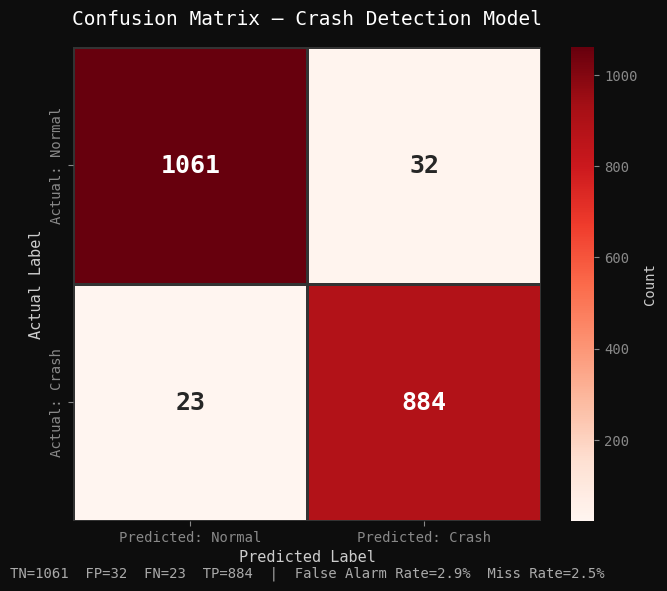

True Negatives  (correct normal) : 1061
False Positives (false alarm)    : 32
False Negatives (missed crash)   : 23
True Positives  (correct crash)  : 884


In [9]:
#confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted: Normal','Predicted: Crash'],
            yticklabels=['Actual: Normal','Actual: Crash'],
            linewidths=1, linecolor='#333',
            annot_kws={'size': 18, 'weight': 'bold'},
            ax=ax, cbar_kws={'label': 'Count'})

ax.set_title('Confusion Matrix — Crash Detection Model', 
             color='white', fontsize=14, pad=16)
ax.set_ylabel('Actual Label', fontsize=11)
ax.set_xlabel('Predicted Label', fontsize=11)

# annotate cells
tn, fp, fn, tp = cm.ravel()
ax.text(0.5, -0.12, 
        f'TN={tn}  FP={fp}  FN={fn}  TP={tp}  |  '
        f'False Alarm Rate={fp/(fp+tn)*100:.1f}%  Miss Rate={fn/(fn+tp)*100:.1f}%',
        transform=ax.transAxes, ha='center', fontsize=10, color='#aaaaaa')

plt.tight_layout()
plt.show()

print(f"True Negatives  (correct normal) : {tn}")
print(f"False Positives (false alarm)    : {fp}")
print(f"False Negatives (missed crash)   : {fn}")
print(f"True Positives  (correct crash)  : {tp}")


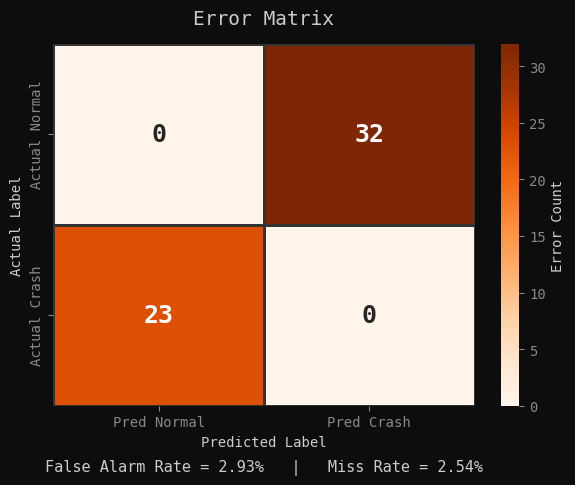

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Extract values
tn, fp, fn, tp = cm.ravel()

# Error matrix (only mistakes)
error_matrix = np.array([[0, fp],
                         [fn, 0]])

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(error_matrix, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred Normal','Pred Crash'],
            yticklabels=['Actual Normal','Actual Crash'],
            linewidths=1, linecolor='#333',
            annot_kws={'size': 18, 'weight': 'bold'},
            cbar_kws={'label': 'Error Count'},
            ax=ax)

ax.set_title('Error Matrix', fontsize=14, pad=14)
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')

# Error rates
false_alarm_rate = fp / (fp + tn)
miss_rate = fn / (fn + tp)

ax.text(0.5, -0.18,
        f'False Alarm Rate = {false_alarm_rate*100:.2f}%   |   Miss Rate = {miss_rate*100:.2f}%',
        transform=ax.transAxes, ha='center', fontsize=11)

plt.tight_layout()
plt.show()

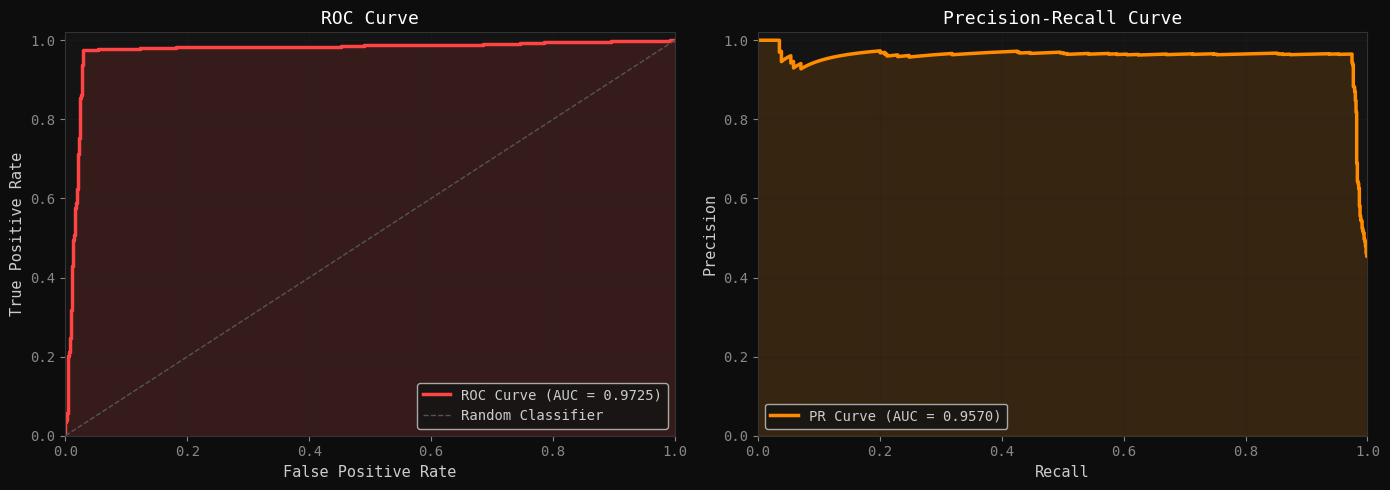

ROC-AUC Score : 0.9725
PR-AUC Score  : 0.9570


In [10]:
#roc curve and precision recall curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
axes[0].plot(fpr, tpr, color='#ff4444', lw=2.5,
             label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0,1],[0,1], color='#555555', lw=1, ls='--', label='Random Classifier')
axes[0].fill_between(fpr, tpr, alpha=0.15, color='#ff4444')
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curve', color='white', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])

# Precision-Recall
pr_prec, pr_rec, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(pr_rec, pr_prec)
axes[1].plot(pr_rec, pr_prec, color='#ff8c00', lw=2.5,
             label=f'PR Curve (AUC = {pr_auc:.4f})')
axes[1].fill_between(pr_rec, pr_prec, alpha=0.15, color='#ff8c00')
axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision-Recall Curve', color='white', fontsize=13)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0,1]); axes[1].set_ylim([0,1.02])

plt.tight_layout()
plt.show()
print(f"ROC-AUC Score : {roc_auc:.4f}")
print(f"PR-AUC Score  : {pr_auc:.4f}")


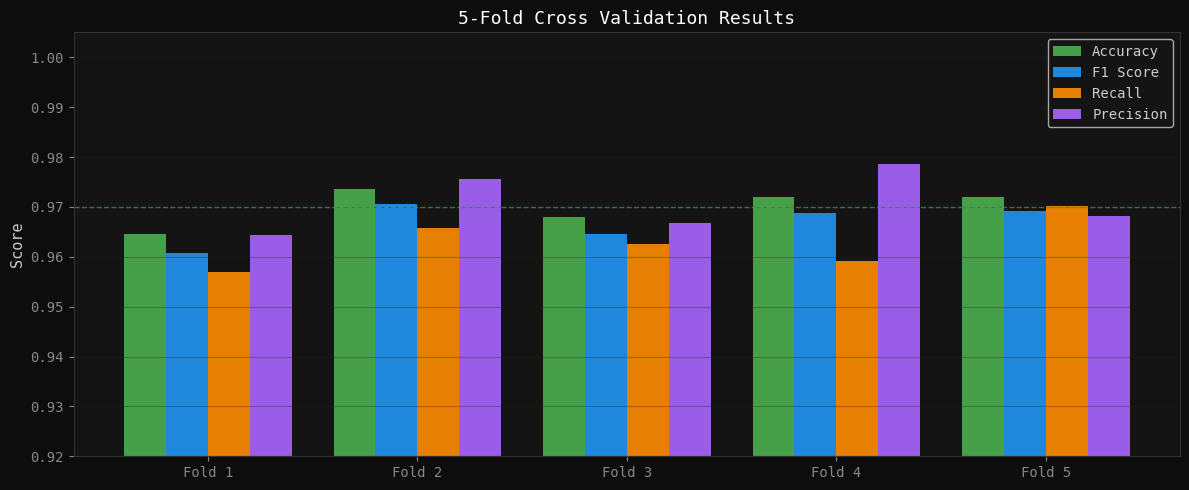

Metric             Mean      Std      Min      Max
----------------------------------------------
Accuracy         0.9700   0.0033   0.9645   0.9735
F1               0.9668   0.0036   0.9607   0.9706
Recall           0.9630   0.0047   0.9570   0.9703
Precision        0.9707   0.0054   0.9644   0.9786


In [12]:
#5fold cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc  = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
cv_f1   = cross_val_score(model, X, y, cv=cv, scoring='f1')
cv_rec  = cross_val_score(model, X, y, cv=cv, scoring='recall')
cv_prec = cross_val_score(model, X, y, cv=cv, scoring='precision')

fig, ax = plt.subplots(figsize=(12, 5))
folds = [f'Fold {i+1}' for i in range(5)]
x = np.arange(5)
w = 0.2

bars_acc  = ax.bar(x - 1.5*w, cv_acc,  w, label='Accuracy',  color='#4caf50', alpha=0.9)
bars_f1   = ax.bar(x - 0.5*w, cv_f1,   w, label='F1 Score',  color='#2196f3', alpha=0.9)
bars_rec  = ax.bar(x + 0.5*w, cv_rec,  w, label='Recall',    color='#ff8c00', alpha=0.9)
bars_prec = ax.bar(x + 1.5*w, cv_prec, w, label='Precision', color='#aa66ff', alpha=0.9)

ax.set_xticks(x); ax.set_xticklabels(folds)
ax.set_ylim([0.92, 1.005])
ax.set_title('5-Fold Cross Validation Results', color='white', fontsize=13)
ax.set_ylabel('Score', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(cv_acc.mean(), color='#4caf50', ls='--', lw=1, alpha=0.6)

plt.tight_layout()
plt.show()

print(f"{'Metric':<14} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 46)
for name, scores in [('Accuracy',cv_acc),('F1',cv_f1),('Recall',cv_rec),('Precision',cv_prec)]:
    print(f"{name:<14} {scores.mean():>8.4f} {scores.std():>8.4f} {scores.min():>8.4f} {scores.max():>8.4f}")


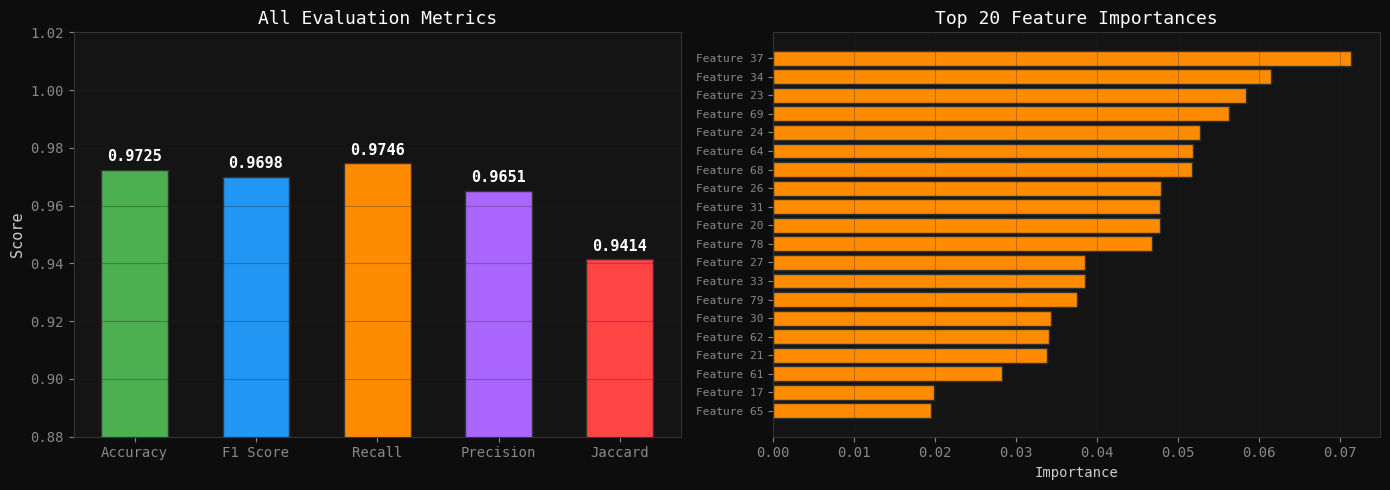


   FINAL MODEL SUMMARY
   Dataset           : 10,000 samples, 80 features
   Train / Test      : 8,000 / 2,000
   Model             : Random Forest (200 trees)
   Accuracy          : 97.25%
   F1 Score          : 0.9698
   Recall            : 0.9746
   Precision         : 0.9651
   Jaccard Index     : 0.9414
   CV Accuracy       : 97.00% ± 0.33%


In [13]:
#metrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric_names  = ['Accuracy', 'F1 Score', 'Recall', 'Precision', 'Jaccard']
metric_values = [acc, f1, rec, prec, jac]
metric_colors = ['#4caf50', '#2196f3', '#ff8c00', '#aa66ff', '#ff4444']

bars = axes[0].bar(metric_names, metric_values, color=metric_colors,
                   edgecolor='#333', width=0.55)
axes[0].set_ylim([0.88, 1.02])
axes[0].set_title('All Evaluation Metrics', color='white', fontsize=13)
axes[0].set_ylabel('Score', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, metric_values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11,
                 color='white', fontweight='bold')

importances = model.feature_importances_
top20_idx   = np.argsort(importances)[-20:][::-1]
top20_imp   = importances[top20_idx]
feat_labels = [f'Feature {i}' for i in top20_idx]

axes[1].barh(range(20), top20_imp[::-1], color='#ff8c00', edgecolor='#333')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(feat_labels[::-1], fontsize=8)
axes[1].set_title('Top 20 Feature Importances', color='white', fontsize=13)
axes[1].set_xlabel('Importance', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "="*55)
print("   FINAL MODEL SUMMARY")
print("="*55)
print(f"   Dataset           : 10,000 samples, 80 features")
print(f"   Train / Test      : 8,000 / 2,000")
print(f"   Model             : Random Forest (200 trees)")
print(f"   Accuracy          : {acc*100:.2f}%")
print(f"   F1 Score          : {f1:.4f}")
print(f"   Recall            : {rec:.4f}")
print(f"   Precision         : {prec:.4f}")
print(f"   Jaccard Index     : {jac:.4f}")
print(f"   CV Accuracy       : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%")



In [ ]:
error metrices